# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes
- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---

### Bibliotecas

In [25]:
# Básicas
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [26]:
# Modelos
from keras.callbacks import EarlyStopping
from keras.layers import (
    Activation,
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input,
    MaxPooling2D,
)
from keras.models import Sequential
from keras.optimizers import SGD, Adam
from keras.utils import to_categorical

In [27]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---

### Data:

##### 1. Lectura de los datos

In [28]:
data_folder = Path("../../data/classification/")
# original_folder = data_folder / "original"
processed_folder = data_folder / "processed"

In [29]:
# Metadata
metadata_df = pd.read_csv(processed_folder / "sample_64x64_10570.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,110581,0
1,53890,0
2,268229,0
3,69751,0
4,294591,0


In [30]:
# Files
processed_images = np.load(processed_folder / "sample_64x64_10570.npz")
files = processed_images.files
print(files[:10])
print(len(files))

['110581', '53890', '268229', '69751', '294591', '287069', '58579', '49874', '17922', '7030']
10570


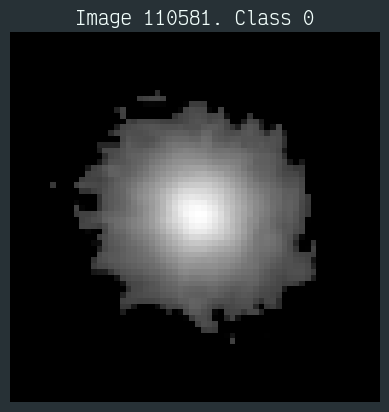

In [31]:
# Ejemplo
img_name = files[0]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

In [35]:
images_array = np.empty((len(metadata_df), 64, 64))

for i, img_name in enumerate(processed_images):
    image = processed_images[img_name]
    if image.max() > 1:
        raise Exception(f"wot?: {image.max()}")
    images_array[i] = image

In [36]:
# Aseguramos la misma cantidad de etiquetas que de imágenes, y congruencia de tamaños
print(images_array.shape, metadata_df["class"].shape)

(10570, 64, 64) (10570,)


##### 2. Preparación de datos en entrenamiento y prueba

In [37]:
# objeto para los datos
@dataclass
class Data:
    x_train: Any
    y_train: Any
    x_valid: Any = None
    y_valid: Any = None
    x_test: Any = None
    y_test: Any = None

In [38]:
# train vs test
x_train, x_test, y_train, y_test = train_test_split(
    images_array.astype("float32"),
    metadata_df["class"].astype("int8"),
    test_size=0.2,
    random_state=35,
    stratify=metadata_df["class"].astype("int8"),
)

# train vs validation
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=35,
    stratify=y_train,
)

# Se guarda en nuestro objeto
data = Data(
    x_train=x_train[..., None],
    y_train=np.array(y_train),
    x_valid=x_valid[..., None],
    y_valid=np.array(y_valid),
    x_test=x_test[..., None],
    y_test=np.array(y_test),
)

---

### Modelo 1. CNN:

In [39]:
def build_binary_cnn():
    model = Sequential()

    model.add(
        Conv2D(
            filters=16,
            kernel_size=3,
            padding="same",
            activation="relu",
            input_shape=data.x_train.shape[1:],
        )
    )
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(0.3))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.4))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=1e-4)
    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,  # type: ignore
        metrics=["accuracy"],
    )

    return model

In [40]:
def visualize_training(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend(["training", "validation"], loc="lower right")
    plt.show()

    # training vs validation loss
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title("loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")
    plt.legend(["training", "validation"], loc="upper right")
    plt.show()

In [41]:
# Callbacks para el fit del modelo, funcionan para encontrar el mejor epoch
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [42]:
cnn_model = build_binary_cnn()
cnn_model.summary()

/home/toutl/icd/lmd/project/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,417 (892.25 KB)

 Trainable params: 228,385 (892.13 KB)

 Non-trainable params: 32 (128.00 B)

In [43]:
# Checar
display(
    data.x_train.shape,
    data.y_train.shape,
    data.x_valid.shape,
    data.y_valid.shape,
    data.x_test.shape,
    data.y_test.shape,
)

(6764, 64, 64, 1)

(6764,)

(1692, 64, 64, 1)

(1692,)

(2114, 64, 64, 1)

(2114,)

In [44]:
print(data.x_train.shape)
print(data.x_train.min(), data.x_train.max())

(6764, 64, 64, 1)
0.0 0.98828125


In [45]:
hist_cnn = cnn_model.fit(
    data.x_train,
    data.y_train,
    batch_size=32,
    epochs=20,
    validation_data=(data.x_valid, data.y_valid),
    callbacks=[early_stop],
)

Epoch 1/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.5931 - loss: 0.6643 - val_accuracy: 0.6046 - val_loss: 0.6767
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6283 - loss: 0.6425 - val_accuracy: 0.7204 - val_loss: 0.6501
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6705 - loss: 0.6174 - val_accuracy: 0.6158 - val_loss: 0.6299
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.6795 - loss: 0.6033 - val_accuracy: 0.7701 - val_loss: 0.5470
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7204 - loss: 0.5709 - val_accuracy: 0.7677 - val_loss: 0.5286
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7295 - loss: 0.5537 - val_accuracy: 0.7843 - val_loss: 0.4957
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7360 - loss: 0.5389 - val_accuracy: 0.7890 - val_loss: 0.4863
Epoch 8/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.7414 - loss: 0.5323 - val_ac

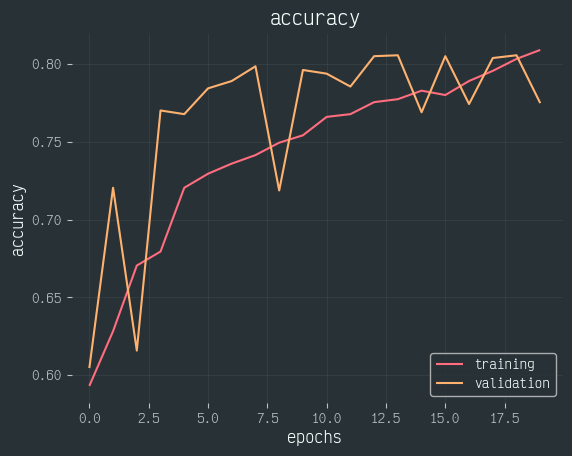

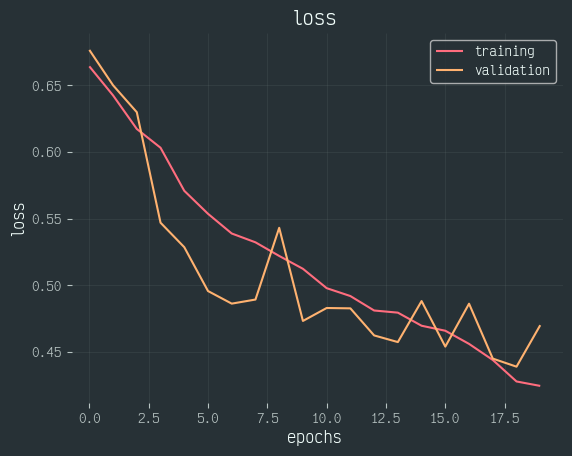

In [46]:
visualize_training(hist_cnn)

In [49]:
score_cnn = cnn_model.evaluate(data.x_test, data.y_test, verbose=0)
print(f"Accuracy CNN: {score_cnn[1] * 100:.2f}%")

Accuracy CNN: 76.77%
